In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# Neural Network

In [ ]:
class NeuralNetwork:
    def __init__(self,layers:list,activation:str,output_activation:str):
        self.layers = layers

        self.weights = []
        self.bias = []
        self.loss = []

        for index in range(len(self.layers)-1):
            self.weights.append(np.random.random((self.layers[index],self.layers[index+1])))
            self.bias.append(np.random.random((1,self.layers[index+1])))
        
        print(self.weights)
        print(self.bias)

    def forward_propogation(self):
        self.input = self.X
        
        for i in range(len(self.layers)-1):
            if(i==len(self.layers)-2):
                output = self.sigmoid(np.matmul(self.input,self.weights[i]) + self.bias[i])
            else:
                output = self.tanh(np.matmul(self.input,self.weights[i]) + self.bias[i])
            self.layer_output.append(output)
            self.input = output
        return output

    def sigmoid(self,x):
        return 1/(1+np.exp(-x))

    def tanh(self,x):
        return np.tanh(x)

    def predict(self,points,threshold = 0.5):
        return np.array([1 if x> threshold else 0 for x in points])

    def fit(self,X,y, n_iter = 1000, lr = 0.01):
        self.X = X
        self.y = y.reshape(-1,1) 
        for iter in range(n_iter):
            self.layer_output = [self.X]
            self.yp = self.forward_propogation().reshape(-1,1)
            loss = np.sum(-self.y*np.log(np.clip(self.yp,1e-8,1-1e-8)) - (1-self.y)*(np.log(np.clip(1-self.yp,1e-8,1-1e-8))))
            self.loss.append(loss/len(self.y))
            for l in range(len(self.layers)-1,0,-1):
                if(l==len(self.layers)-1):
                    delta = -(self.y - self.yp)/len(self.y)
                else:
                    delta = delta_l1@self.weights[l].T*(1-self.layer_output[l]**2)

                delta_l1 = delta
                self.weights[l-1] = self.weights[l-1] - lr * self.layer_output[l-1].T@delta
                self.bias[l-1] = self.bias[l-1] - lr * delta
        return self.predict(self.yp)
        


(100, 2)
(100,)


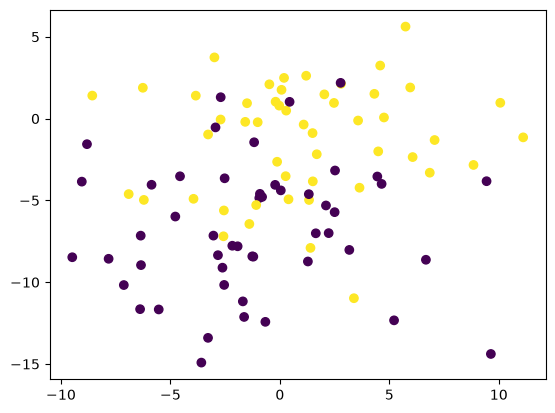

In [42]:
data = make_blobs(n_samples=100,n_features=2,centers=2,cluster_std=4)
X = data[0]
y = data[1]
print(X.shape)
print(y.shape)
plt.scatter(X[:,0],X[:,1],c=y)

In [43]:
nn = NeuralNetwork([X.shape[1],5,3,1],"tanh","sigmoid")
predict = nn.fit(X,y,n_iter=1000)

[array([[0.07995376, 0.10376897, 0.15179648, 0.17427823, 0.73037253],
       [0.48056981, 0.36748833, 0.91847745, 0.10117873, 0.7152978 ]]), array([[0.60869937, 0.53249509, 0.65547565],
       [0.41423095, 0.67868345, 0.41251146],
       [0.90932849, 0.40859766, 0.58387685],
       [0.05795372, 0.78998914, 0.39509754],
       [0.81054771, 0.95388218, 0.12651018]]), array([[0.39031174],
       [0.55697982],
       [0.98175967]])]
[array([[0.58013947, 0.42327225, 0.14319215, 0.43771764, 0.85612933]]), array([[0.68840328, 0.25773991, 0.83683744]]), array([[0.5039083]])]


Text(0.5, 0.98, 'Accuracy: 0.8')

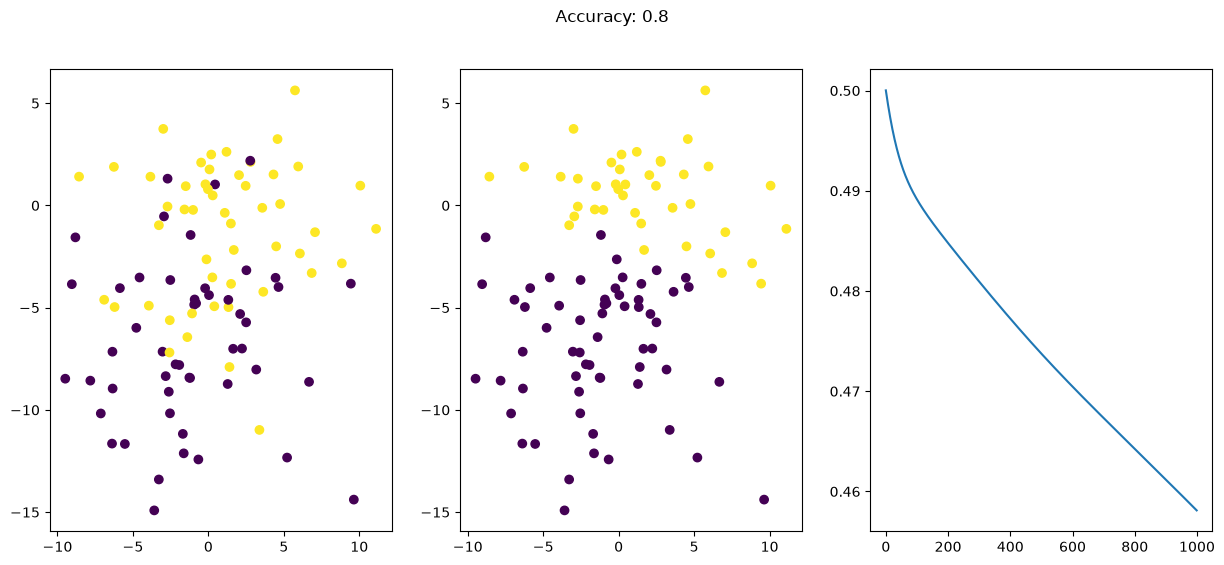

In [44]:
acc = np.sum(y == predict)/len(y)
fig,ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].scatter(X[:,0],X[:,1],c=y)
ax[1].scatter(X[:,0],X[:,1],c=predict)
ax[2].plot(nn.loss)
fig.suptitle(f"Accuracy: {acc}")

In [45]:
nn.layer_output

[array([[  4.7553943 ,   0.06961671],
        [  0.07643007,   1.76024941],
        [  0.39522317,  -4.93215015],
        [  5.95430936,   1.90304961],
        [  6.8476367 ,  -3.3057275 ],
        [  1.08777689,  -0.36301025],
        [  4.58315995,   3.24469666],
        [ -6.355305  ,  -7.15397828],
        [  4.64755537,  -3.99111531],
        [  1.33344315,  -4.97280472],
        [ -2.17199478,  -7.77067537],
        [  3.57317519,  -0.11692128],
        [  2.79377481,   2.12834178],
        [  0.04269575,  -4.38638727],
        [  9.63839141, -14.38640775],
        [  6.67147894,  -8.62817369],
        [ -5.8603384 ,  -4.04398247],
        [  1.5048941 ,  -3.83479074],
        [ -3.03446323,  -7.15154868],
        [ -0.47927231,   2.09755805],
        [  5.74002171,   5.6253442 ],
        [ -1.25936527,  -8.41977014],
        [  1.64182218,  -7.0101629 ],
        [  0.26553137,  -3.51909095],
        [ -1.39364184,  -6.44045184],
        [ -0.19392891,   1.03376582],
        [  0